# 0. Setup

In [94]:
# Librerías
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
from scipy import stats


# Configuración para ver más filas y columnas
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 100)

# Deshabilitar notación científica
pd.options.display.float_format = '{:.2f}'.format

# 1. Entendimiento inicial de datos

In [95]:
# Cargar datos
df = pq.read_table("data/secop_bienes.parquet").to_pandas()

In [96]:
# Explorar datos
df.head(n=15)

,id_contrato,nombre_entidad,departamento,ciudad,orden,sector,rama,entidad_centralizada,tipo_de_contrato,modalidad_de_contratacion,codigo_de_categoria_principal,objeto_del_contrato,fecha_de_firma,fecha_de_inicio_del_contrato,fecha_de_fin_del_contrato,duraci_n_del_contrato,condiciones_de_entrega,proveedor_adjudicado,documento_proveedor,es_pyme,es_grupo,g_nero_representante_legal,nacionalidad_representante_legal,valor_del_contrato,valor_pagado,valor_facturado,valor_pendiente_de_pago,dias_adicionados,habilita_pago_adelantado,el_contrato_puede_ser_prorrogado,origen_de_los_recursos,destino_gasto,estado_contrato,liquidaci_n,obligaci_n_ambiental,urlproceso
0,CO1.PCCNTR.1000001,PARQUES NACIONALES NATURALES DE COLOMBIA - DIR...,Distrito Capital de Bogotá,No Definido,Territorial,Ambiente y Desarrollo Sostenible,Ejecutivo,Centralizada,Suministros,Mínima cuantía,V1.50161509,Contratar a monto agotable por el sistema de p...,2019-06-19,2019-06-18,2019-12-31,No definido,Como acordado previamente,INDUSTRIAS GUERRERO Y COMPAÑIA S.A.S.,830130048,Si,No,No Definido,CO,17897916.00,17896237,17896237,1679,0,No Definido,Si,Distribuido,Funcionamiento,Cerrado,Si,No,{'url': 'https://community.secop.gov.co/Public...
1,CO1.PCCNTR.1000507,AGENCIA LOGISTICA DE LAS FUERZAS MILITARES,Distrito Capital de Bogotá,Bogotá,Nacional,defensa,Ejecutivo,Centralizada,Suministros,Selección Abreviada de Menor Cuantía,V1.50131612,SUMINISTRO DE HUEVOS CON DESTINO A LOS COMEDOR...,2019-06-23,2019-06-13,2019-11-29,Dia(s),Transporte incluido,Distribuidora Antioqueña AM,21788564,Si,No,Mujer,CO,390000000.00,389999685,389999685,315,0,No,No,Distribuido,Funcionamiento,Cerrado,Si,No,{'url': 'https://community.secop.gov.co/Public...
2,CO1.PCCNTR.1000901,FUERZA AEROESPACIAL COLOMBIANA,Distrito Capital de Bogotá,Bogotá,Nacional,defensa,Ejecutivo,Centralizada,Compraventa,Mínima cuantía,V1.53102701,ADQUISICIÓN DE PRESILLAS BORDADAS AZULES EN CA...,2019-06-18,2019-06-24,2019-09-30,No definido,DAP - Entregado en un punto (lugar de destino ...,FANNY JANETH GUTIERREZ PRIETO,20484821,No,No,Mujer,CO,11970000.00,11970000,11970000,0,0,No Definido,Si,Distribuido,Funcionamiento,terminado,No,No,{'url': 'https://community.secop.gov.co/Public...
3,CO1.PCCNTR.1000908,AGENCIA LOGISTICA DE LAS FUERZAS MILITARES,Distrito Capital de Bogotá,Bogotá,Nacional,defensa,Ejecutivo,Centralizada,Compraventa,Licitación pública,V1.41115300,ADQUISICIÓN DE UN SISTEMA DE SONAR 3D DE ALTA ...,2019-07-25,2019-07-12,2019-11-30,Dia(s),Como acordado previamente,CASCO ANTIGUO,76044753,No,No,Otro,CO,733992000.00,0,0,733992000,0,No,No,Distribuido,Funcionamiento,Cerrado,Si,No,{'url': 'https://community.secop.gov.co/Public...
4,CO1.PCCNTR.1000911,PARQUES NACIONALES NATURALES DE COLOMBIA - DIR...,Bolívar,Cartagena,Territorial,Ambiente y Desarrollo Sostenible,Ejecutivo,Centralizada,Suministros,Mínima cuantía,V1.92121701,Suministro de equipos para la instalación de t...,2019-11-01,2019-06-17,2019-12-30,No definido,No Definido,hr technology sas,900815825,Si,No,No Definido,CO,6000000.00,0,0,6000000,0,No Definido,No,Distribuido,Inversión,Aprobado,No,No,{'url': 'https://community.secop.gov.co/Public...
5,CO1.PCCNTR.1000912,CÁRCEL Y PENITENCIARIA DE MEDIA SEGURIDAD DE N...,Huila,Rivera,Nacional,Ley de Justicia,Ejecutivo,Centralizada,Compraventa,Mínima cuantía,V1.44122003,ADQUISICIÓN DE MATERIALES DE OFICINA Y ELEMENT...,2019-06-19,2019-06-18,2019-08-30,No definido,Como acordado previamente,PAPELERIA EL DESCUENTO DE NEIVA,36183257,Si,No,Mujer,CO,16496353.00,16496353,16496353,0,0,No Definido,No,Distribuido,Funcionamiento,Cerrado,No,No,{'url': 'https://community.secop.gov.co/Public...
6,CO1.PCCNTR.1000913,INVIAS,Distrito Capital de Bogotá,Bogotá,Nacional,Transporte,Ejecutivo,Centralizada,Suministros,Mínima cuantía,V1.72141000,SUMINISTRO DE MEZCLA ASFÁLTICA VÍA 6006; MÍNIM...,2019-07-11,2019-07-05,2019-07-20,Dia(s),No Definido,Proyectos de Ingeniería Cumbre S.A.S.,900868183,Si,No,Hombre,CO,72159089.00,0,0,72159089,0,No Definido,No,Distribuido

In [97]:
# Dimensiones (filas, columnas)
df.shape

(196391, 36)

In [98]:
# Información de los datos
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 196391 entries, 0 to 196390
Data columns (total 36 columns):
 #   Column                            Non-Null Count   Dtype         
---  ------                            --------------   -----         
 0   id_contrato                       196391 non-null  str           
 1   nombre_entidad                    196391 non-null  str           
 2   departamento                      196391 non-null  str           
 3   ciudad                            196391 non-null  str           
 4   orden                             196391 non-null  str           
 5   sector                            196391 non-null  str           
 6   rama                              196391 non-null  str           
 7   entidad_centralizada              196391 non-null  str           
 8   tipo_de_contrato                  196391 non-null  str           
 9   modalidad_de_contratacion         196391 non-null  str           
 10  codigo_de_categoria_principal     196391 no

In [99]:
# Estadísticas descriptivas
df.describe()

,fecha_de_firma,fecha_de_inicio_del_contrato,fecha_de_fin_del_contrato,valor_del_contrato,valor_pagado,valor_facturado,valor_pendiente_de_pago,dias_adicionados
count,196391,193951,196391,196391.00,196391.00,196391.00,196391.00,196391.00
mean,2023-02-27 22:45:53.539622,2023-03-01 13:02:29.326376,2023-06-11 04:37:50.596921,65824255027.86,119491099.77,148409156.65,65704762982.84,5.11
min,2019-01-01 00:00:00,2016-06-27 00:00:00,0202-12-31 00:00:00,0.00,0.00,0.00,-84184884.00,0.00
25%,2021-09-10 00:00:00,2021-09-17 00:00:00,2021-12-20 00:00:00,12021214.00,0.00,0.00,0.00,0.00
50%,2023-05-30 00:00:00,2023-06-05 00:00:00,2023-10-27 00:00:00,33600000.00,0.00,3207328.00,6717571.00,0.00
75%,2024-11-07 00:00:00,2024-11-14 00:00:00,2024-12-31 00:00:00,100000000.00,28120772.50,37086225.00,42411892.00,0.00
max,2025-12-31 00:00:00,2026-12-16 00:00:00,2065-01-31 00:00:00,12858450316000000.00,594403394800.00,594503164818.00,12858450316000000.00,14276.00
std,NaN,NaN,NaN,29015352967837.05,2444116099.87,2969809583.32,29015353088019.10,40.66


# 1.1. Atributos que consideramos más importantes

## 1.1.1. Atributos objetivo

El objetivo de negocio es identificar patrones, tendencias y oportunidades que se puedan correlacionar con desviaciones del plan inicial de la ejecución de un contrato.

Decidimos agrupar por senales los atributos, según:
- Desviación de tiempo
- Desviación de recursos
- Desviación de cierre

### 1.1.1.1. Desviación de tiempo
Atributo: `dias_adicionados`

Se realizará un análisis univariado de esta variable **numérica** (conteo de días adicionados al plazo).


In [100]:
print(df['dias_adicionados'].describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, .95, .99, .999]
))
print("Sesgo:", df['dias_adicionados'].skew())
print("Kurtosis:", df['dias_adicionados'].kurtosis())

count   196391.00
mean         5.11
std         40.66
min          0.00
1%           0.00
5%           0.00
25%          0.00
50%          0.00
75%          0.00
95%         30.00
99%        122.00
99.9%      316.00
max      14276.00
Name: dias_adicionados, dtype: float64
Sesgo: 222.19171449720685
Kurtosis: 77269.88230930727


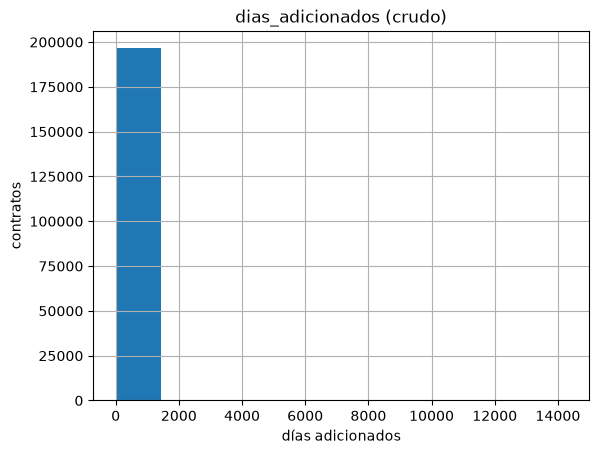

In [101]:
df['dias_adicionados'].hist()
plt.xlabel('días adicionados')
plt.ylabel('contratos')
plt.title('dias_adicionados (crudo)')
plt.show()

`dias_adicionados` es una variable **cero-inflada**, con cola derecha y un outlier extremo. Pandas reporta **kurtosis excesiva** (una normal vale 0, no 3).

- Sesgo 222 y kurtosis 77,270: masa a la izquierda y colas mucho más pesadas que una normal.
- Mediana, p25 y p75 en 0: la mayoría de contratos no se prorrogan (~90.5%).
- Media 5.11 arrastrada por la cola; no describe al contrato típico.
- p99 = 122 días vs máximo = 14,276 días (~39 años): se va a excluir este dato, *suponiendo* una validación con un experto de negocio. 

In [102]:
df['dias_adicionados_v2'] = df['dias_adicionados'].where(
    df['dias_adicionados'] != df['dias_adicionados'].max()
)

print("Nulos en dias_adicionados_v2:", df['dias_adicionados_v2'].isna().sum())
print("Máximo original:", df['dias_adicionados'].max())
print("Máximo v2:", df['dias_adicionados_v2'].max())
print(df['dias_adicionados_v2'].describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, .95, .99, .999]
))
print("Sesgo:", df['dias_adicionados_v2'].skew())
print("Kurtosis:", df['dias_adicionados_v2'].kurtosis())

Nulos en dias_adicionados_v2: 1
Máximo original: 14276
Máximo v2: 874.0
count   196390.00
mean         5.03
std         24.83
min          0.00
1%           0.00
5%           0.00
25%          0.00
50%          0.00
75%          0.00
95%         30.00
99%        122.00
99.9%      315.61
max        874.00
Name: dias_adicionados_v2, dtype: float64
Sesgo: 9.111907156819608
Kurtosis: 127.40991670265376


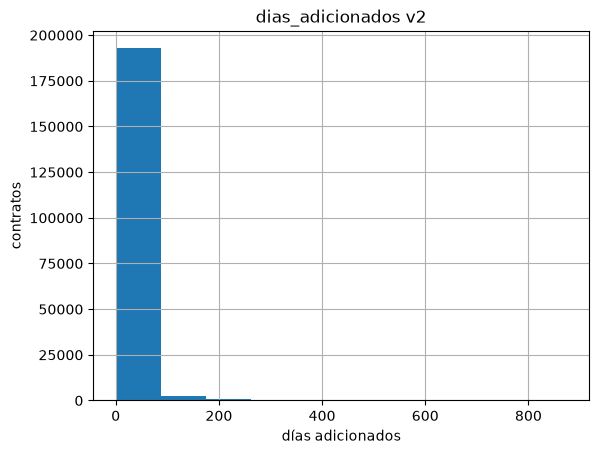

In [103]:
df['dias_adicionados_v2'].hist()
plt.xlabel('días adicionados')
plt.ylabel('contratos')
plt.title('dias_adicionados v2')
plt.show()


También se hizo un análisis de sólo contratos prorrogados, para entender mejor el problema.

count   18670.00
mean       52.96
std        62.82
min         1.00
1%          2.00
5%          5.00
25%        15.00
50%        31.00
75%        62.00
95%       181.00
99%       322.00
99.9%     482.66
max       874.00
Name: dias_adicionados_v2, dtype: float64
Sesgo: 3.1902195298581604
Kurtosis: 16.914264813891865


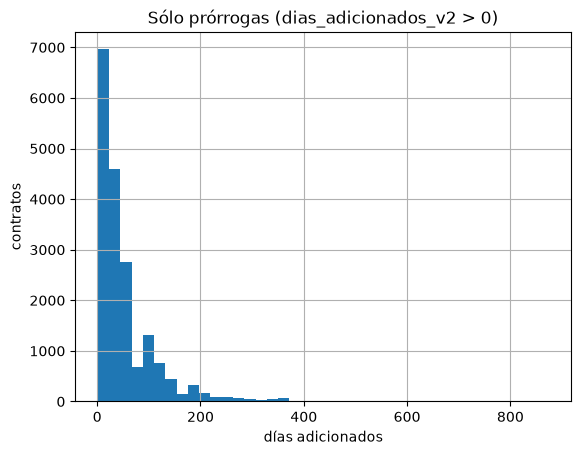

In [104]:
prorrogas = df.loc[df['dias_adicionados_v2'] > 0, 'dias_adicionados_v2']

print(prorrogas.describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, .95, .99, .999]
))
print("Sesgo:", prorrogas.skew())
print("Kurtosis:", prorrogas.kurtosis())

prorrogas.hist(bins=40)
plt.xlabel('días adicionados')
plt.ylabel('contratos')
plt.title('Sólo prórrogas (dias_adicionados_v2 > 0)')
plt.show()

Conclusión: la prórroga es **poco frecuente**, y cuando ocurre suele ser corta.

- Solo **18,671 contratos (9.5%)** tienen `dias_adicionados > 0`. El resto no se desvía en plazo.
- Entre los prorrogados (sin el 14,276): mediana **31 días**, media **53**, p75 **62**. Casi la mitad se extiende a lo sumo un mes; ~83% a lo sumo 90 días.
- Sigue habiendo cola derecha (sesgo ~3.2): p95 = 181 días y 77 contratos superan un año (máximo 874). Son pocos, pero son los de mayor riesgo operativo.
- Para focalizar supervisión, el indicador útil en firma no es el promedio de días (no representa al típico), sino **si el contrato se prorroga** y, en segunda instancia, las prórrogas largas (>90 o >180 días).
 

## 1.1.1.2 Desviación de recursos

Atributo 1: `valor_del_contrato`

Atributo 2: `valor_pagado`

Análisis univariado de variables **numéricas** (pesos). En `valor_del_contrato` se anulan los ceros: un contrato de compraventa/suministro por 0 COP no tiene sentido. En `valor_pagado` los ceros **sí se conservan**: son la señal de presupuesto no ejecutado.


count              196391.00
mean          65824255027.86
std        29015352967837.05
min                     0.00
1%                 701068.00
5%                2309772.50
25%              12021214.00
50%              33600000.00
75%             100000000.00
95%             800000000.00
99%            4118481942.98
99.9%         30959141166.37
max     12858450316000000.00
Name: valor_del_contrato, dtype: float64
Sesgo: 443.16015148594323
Kurtosis: 196390.94657048953


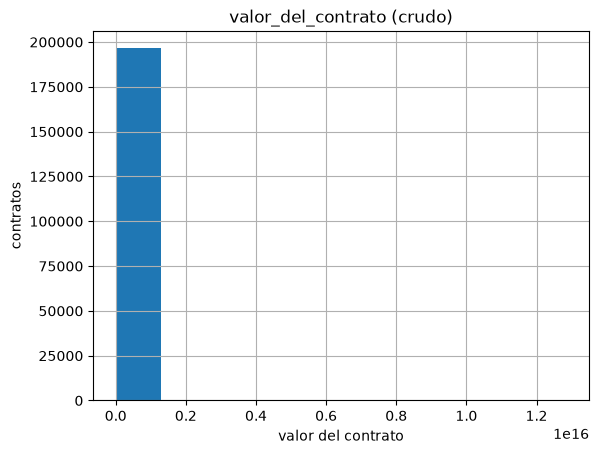

In [105]:
print(df['valor_del_contrato'].describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, .95, .99, .999]
))
print("Sesgo:", df['valor_del_contrato'].skew())
print("Kurtosis:", df['valor_del_contrato'].kurtosis())

df['valor_del_contrato'].hist()
plt.xlabel('valor del contrato')
plt.ylabel('contratos')
plt.title('valor_del_contrato (crudo)')
plt.show()

El histograma crudo no se lee: un solo contrato vale **12,858,450,316,000,000** COP (compra de tres bienes), ~400,000 veces el p99.9. Sesgo 443 y kurtosis 196,391. Mediana 33.6 millones vs media 65,824 millones. También hay **188 ceros**, que no corresponden a un contrato de bienes. 

En `valor_del_contrato_v2` se anula el máximo y los ceros, sin borrar las filas. Vamos a suponer que esta decisión también se validó con un experto del negocio.

Ceros originales en valor_del_contrato: 188
Nulos en valor_del_contrato_v2: 189
Máximo original: 1.2858450316e+16
Máximo v2: 2846224257835.0
Mínimo v2: 0.01
count          196202.00
mean        350867744.35
std       10706517268.26
min                 0.01
1%             756845.10
5%            2354620.00
25%          12085031.50
50%          33681770.00
75%         100000000.00
95%         800000000.00
99%        4119983132.70
99.9%     30817943546.68
max     2846224257835.00
Name: valor_del_contrato_v2, dtype: float64
Sesgo: 200.00553393198126
Kurtosis: 46306.79031015586


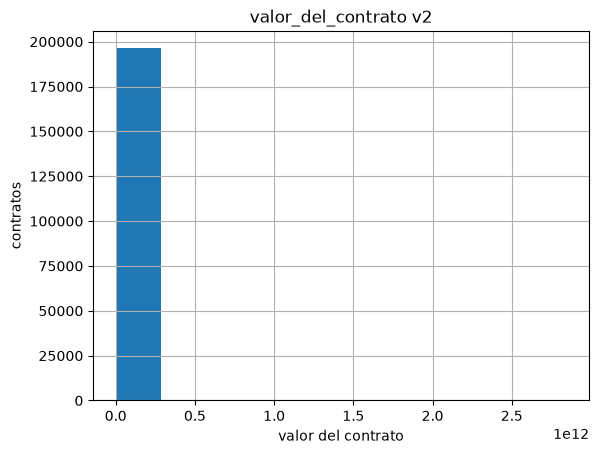

In [106]:
df['valor_del_contrato_v2'] = df['valor_del_contrato'].where(
    (df['valor_del_contrato'] != df['valor_del_contrato'].max())
    & (df['valor_del_contrato'] > 0)
)

print("Ceros originales en valor_del_contrato:", (df['valor_del_contrato'] == 0).sum())
print("Nulos en valor_del_contrato_v2:", df['valor_del_contrato_v2'].isna().sum())
print("Máximo original:", df['valor_del_contrato'].max())
print("Máximo v2:", df['valor_del_contrato_v2'].max())
print("Mínimo v2:", df['valor_del_contrato_v2'].min())
print(df['valor_del_contrato_v2'].describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, .95, .99, .999]
))
print("Sesgo:", df['valor_del_contrato_v2'].skew())
print("Kurtosis:", df['valor_del_contrato_v2'].kurtosis())

df['valor_del_contrato_v2'].hist()
plt.xlabel('valor del contrato')
plt.ylabel('contratos')
plt.title('valor_del_contrato v2')
plt.show()


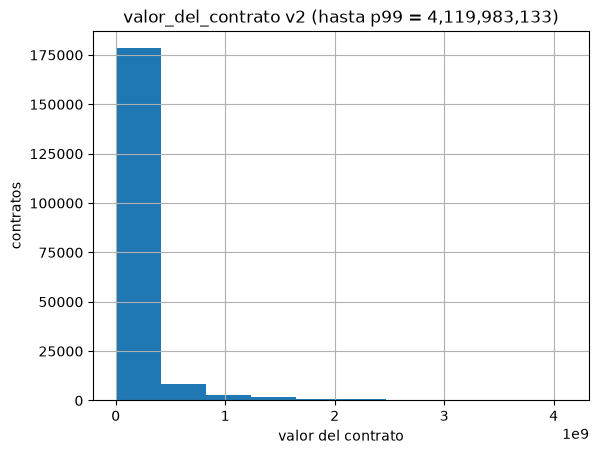

In [107]:
# Se va a graficar p99 para tener un gráfico no tan afectado por los outliers.
p99 = df['valor_del_contrato_v2'].quantile(0.99)
df.loc[df['valor_del_contrato_v2'] <= p99, 'valor_del_contrato_v2'].hist()
plt.xlabel('valor del contrato')
plt.ylabel('contratos')
plt.title(f'valor_del_contrato v2 (hasta p99 = {p99:,.0f})')
plt.show()


Conclusión: `valor_del_contrato` es de cola pesada. Se limpian **un outlier extremo** y **los ceros**.

- Un valor de contrato = 0 no tiene sentido en compraventa/suministros (188 filas, ~0.1%). Se anulan en `v2`, igual que el 12.86e15. Las filas se conservan para el resto de atributos.
- Tras esa limpieza, la mediana sigue en **~33.6 millones** y la media baja a **~351 millones**. El contrato típico es de mínima/menor cuantía; la media la empujan contratos grandes reales.
- p75 = 100 millones, p99 ≈ 4,117 millones, máximo v2 ≈ 2.85 billones. Sigue el sesgo (~200): muchos contratos chicos y unos pocos enormes.
- Para supervisión, el valor de firma sí es un atributo útil (magnitud del riesgo fiscal), pero hay que mirar **medianas/percentiles o umbrales** (p. ej. p95), no la media.


Atributo 2: `valor_pagado`

Mismo procedimiento descriptivo. **No** se filtran ceros ni se anula el máximo: el 0 es informativo (no se ha pagado) y el máximo (~594 mil millones) es coherente con el valor del contrato.


count         196391.00
mean       119491099.77
std       2444116099.87
min                0.00
1%                 0.00
5%                 0.00
25%                0.00
50%                0.00
75%         28120772.50
95%        312000000.00
99%       1714289389.80
99.9%    12397799847.74
max     594403394800.00
Name: valor_pagado, dtype: float64
Sesgo: 168.34564944454127
Kurtosis: 36616.255398901856
Ceros en valor_pagado: 107639
Proporción de ceros: 0.5480851973868456


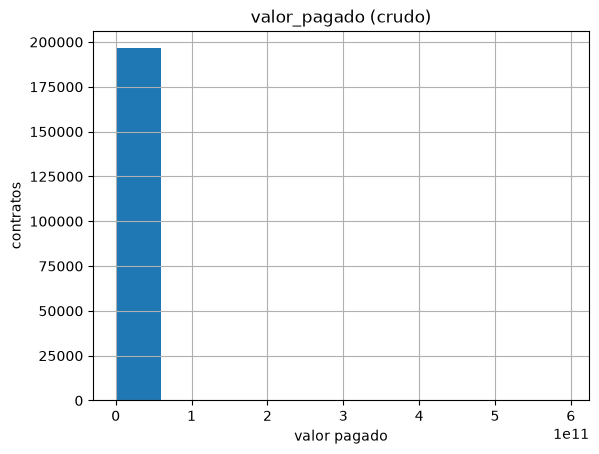

In [108]:
print(df['valor_pagado'].describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, .95, .99, .999]
))
print("Sesgo:", df['valor_pagado'].skew())
print("Kurtosis:", df['valor_pagado'].kurtosis())
print("Ceros en valor_pagado:", (df['valor_pagado'] == 0).sum())
print("Proporción de ceros:", (df['valor_pagado'] == 0).mean())

df['valor_pagado'].hist()
plt.xlabel('valor pagado')
plt.ylabel('contratos')
plt.title('valor_pagado (crudo)')
plt.show()


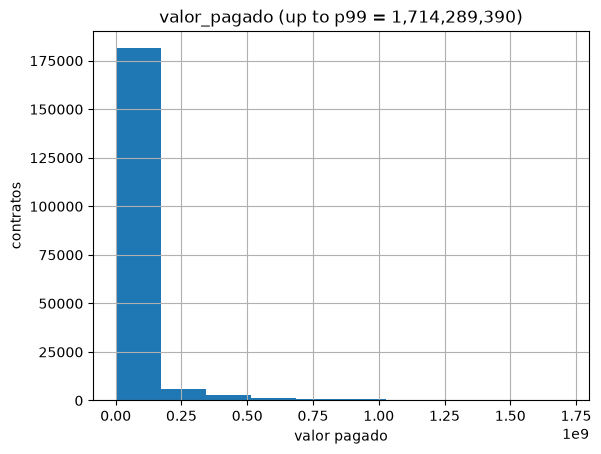

In [109]:
p99_pagado = df['valor_pagado'].quantile(0.99)
df.loc[df['valor_pagado'] <= p99_pagado, 'valor_pagado'].hist()
plt.xlabel('valor pagado')
plt.ylabel('contratos')
plt.title(f'valor_pagado (up to p99 = {p99_pagado:,.0f})')
plt.show()


Conclusión: `valor_pagado` también es de cola derecha (sesgo 168, kurtosis 36,616), pero los ceros **sí son el caso típico** y no se deben borrar.

- **107,639 contratos (54.8%)** tienen pagado = 0. Mediana 0, media ~119 millones. Si filtráramos ceros, tiraríamos justo la señal de subejecución del enunciado.
- A diferencia de `valor_del_contrato`, el máximo (594 mil millones) cuadra con el valor contratado de ese registro; no se trata como error ni se crea una `_v2`.
- El cruce útil más adelante es la **razón pagado / contratado** sobre contratos ya cerrados, no el histograma de pagos en crudo ni el subconjunto pagado > 0.


## 1.1.1.3. Desviación de cierre
Atributo: `estado_contrato`

Análisis univariado de variable **categórica**. Mostramos frecuencias y un gráfico de barras.


estado_contrato
terminado       54230
En ejecución    51441
Cerrado         46824
Modificado      34462
Aprobado         9211
Suspendido        153
cedido             43
Cancelado          26
Borrador            1
Name: count, dtype: int64

estado_contrato
terminado      0.28
En ejecución   0.26
Cerrado        0.24
Modificado     0.18
Aprobado       0.05
Suspendido     0.00
cedido         0.00
Cancelado      0.00
Borrador       0.00
Name: proportion, dtype: float64
Nulos: 0
Categorías: 9


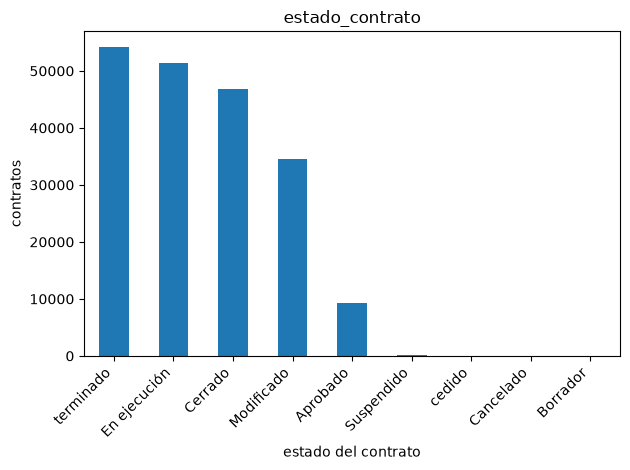

In [110]:
print(df['estado_contrato'].value_counts(dropna=False))
print()
print(df['estado_contrato'].value_counts(dropna=False, normalize=True))
print("Nulos:", df['estado_contrato'].isna().sum())
print("Categorías:", df['estado_contrato'].nunique())

df['estado_contrato'].value_counts().plot(kind='bar')
plt.xlabel('estado del contrato')
plt.ylabel('contratos')
plt.title('estado_contrato')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


Conclusión: `estado_contrato` tiene **9 categorías**, sin nulos. Cuatro estados concentran casi todo el dataset.

- `terminado` 27.6%, `En ejecución` 26.2%, `Cerrado` 23.8%, `Modificado` 17.6%. Juntos son ~95%.
- Casi la mitad **aún no está cerrada**: `En ejecución` + `Modificado` + `Aprobado` + `Suspendido` ≈ 48.5%. Esos contratos no sirven para medir subejecución (un pagado = 0 puede ser solo que todavía no pagan).
- Terminados/cerrados (`terminado` + `Cerrado`) son ~51.5%: ese es el universo razonable para desviación de cierre y de presupuesto.
- Calidad: etiquetas inconsistentes (`terminado` vs `Cerrado`, `cedido` en minúscula). `Borrador` (1) y `Cancelado` (26) son raros; el borrador no debería estar en un extracto de contratos firmados.
- No se crea una `_v2` numérica. Más adelante se filtrarán los estados abiertos para el análisis de outcomes.


## 1.1.2. Sector
Atributo: `sector`

sector
Servicio Público                                      37390
defensa                                               34585
No aplica/No pertenece                                24465
Salud y Protección Social                             22037
Ley de Justicia                                       20377
Trabajo                                               14759
Educación Nacional                                    10231
Ambiente y Desarrollo Sostenible                       8109
Transporte                                             4655
Cultura                                                2792
deportes                                               2610
Hacienda y Crédito Público                             2441
Industria                                              1807
Vivienda, Ciudad y Territorio                          1497
Planeación                                             1319
agricultura                                            1254
interior                         

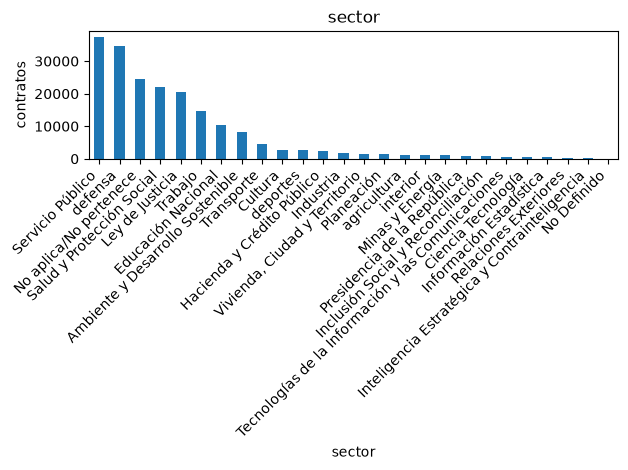

In [111]:
print(df['sector'].value_counts(dropna=False))
print()
print(df['sector'].value_counts(dropna=False, normalize=True))
print("Nulos:", df['sector'].isna().sum())
print("Categorías:", df['sector'].nunique())

df['sector'].value_counts().plot(kind='bar')
plt.xlabel('sector')
plt.ylabel('contratos')
plt.title('sector')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


Conclusión: `sector` es categórica, **26 etiquetas**, sin nulos. Está muy concentrada y tiene problemas de calidad.

- Top 5 ≈ 70%: Servicio Público (19.0%), defensa (17.6%), No aplica/No pertenece (12.5%), Salud (11.2%), Ley de Justicia (10.4%).
- Calidad (menor): mezcla de mayúsculas (`Hacienda y Crédito Público`, `deportes`)
- Calidad: `No aplica/No pertenece` (24,465) no es un sector real; `No Definido` son 9 filas.

## 1.1.3. Tipo de contrato
Atributo: `tipo_de_contrato`

tipo_de_contrato
Suministros    106632
Compraventa     89759
Name: count, dtype: int64

tipo_de_contrato
Suministros   0.54
Compraventa   0.46
Name: proportion, dtype: float64
Nulos: 0
Categorías: 2


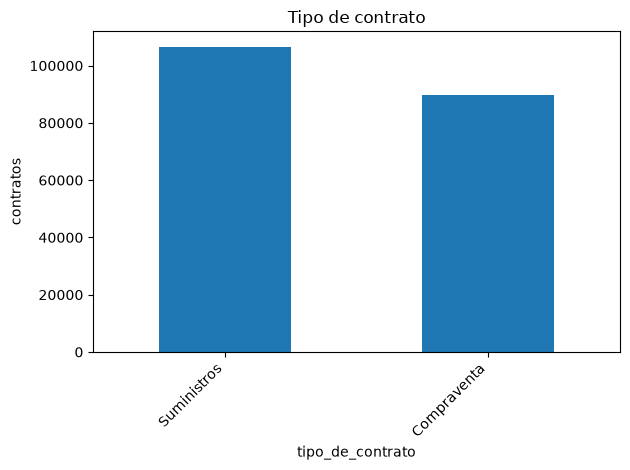

In [112]:
print(df['tipo_de_contrato'].value_counts(dropna=False))
print()
print(df['tipo_de_contrato'].value_counts(dropna=False, normalize=True))
print("Nulos:", df['tipo_de_contrato'].isna().sum())
print("Categorías:", df['tipo_de_contrato'].nunique())

df['tipo_de_contrato'].value_counts().plot(kind='bar')
plt.xlabel('tipo_de_contrato')
plt.ylabel('contratos')
plt.title('Tipo de contrato')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Conclusión: `tipo_de_contrato` es categórica, **2 etiquetas**, sin nulos y sin problemas de calidad.

- `Suministros` 54.3% (106,632) y `Compraventa` 45.7% (89,759). El dataset **solo** trae estos dos (extracto SECOP de bienes); no es un hallazgo sobre toda la contratación pública.
- Medianas parecidas: compraventa ~29.4 millones, suministros ~36.5 millones.
- Como predictor de desviación es **débil** (al menos en crudo): entre finalizados, no pago 41.8% vs 42.8% y prórroga 1.5% vs 1.4%. No sirve para focalizar supervisión por sí solo.
- Más adelante se puede contrastar con un test de proporciones, pero no se espera un efecto grande.


## 1.1.4. Modalidad de contratación
Atributo: `modalidad_de_contratacion`

Análisis univariado de variable **categórica**. Es el atributo de firma más relevante después del valor: indica el grado de competencia.


modalidad_de_contratacion
Mínima cuantía                                                 117753
Selección abreviada subasta inversa                             32907
Contratación régimen especial                                   19250
Selección Abreviada de Menor Cuantía                             8822
Contratación régimen especial (con ofertas)                      6154
Contratación Directa (con ofertas)                               5001
Contratación directa                                             3938
Licitación pública                                               2330
Seleccion Abreviada Menor Cuantia Sin Manifestacion Interes       236
Name: count, dtype: int64

modalidad_de_contratacion
Mínima cuantía                                                0.60
Selección abreviada subasta inversa                           0.17
Contratación régimen especial                                 0.10
Selección Abreviada de Menor Cuantía                          0.04
Contratación régimen es

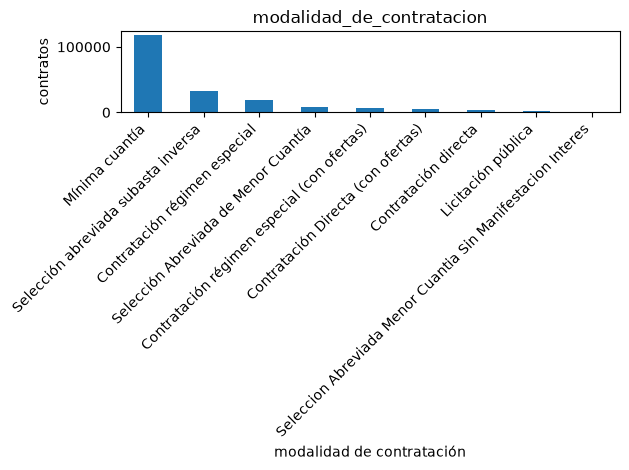

In [113]:
print(df['modalidad_de_contratacion'].value_counts(dropna=False))
print()
print(df['modalidad_de_contratacion'].value_counts(dropna=False, normalize=True))
print("Nulos:", df['modalidad_de_contratacion'].isna().sum())
print("Categorías:", df['modalidad_de_contratacion'].nunique())

df['modalidad_de_contratacion'].value_counts().plot(kind='bar')
plt.xlabel('modalidad de contratación')
plt.ylabel('contratos')
plt.title('modalidad_de_contratacion')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


Conclusión: `modalidad_de_contratacion` es categórica, **9 etiquetas**, sin nulos. Muy concentrada en contratación de bajo monto.

- `Mínima cuantía` es **60%** (117,753). Luego subasta inversa 16.8% y régimen especial 9.8%. `Licitación pública` es solo 1.2%.
- Calidad: no hay duplicados por mayúsculas, pero sí **familias partidas**: `Contratación directa` vs `Contratación Directa (con ofertas)`; `régimen especial` vs `régimen especial (con ofertas)`; una etiqueta sin tildes (`Seleccion Abreviada Menor Cuantia...`, n=236). Para tests se pueden agrupar (mínima / competitiva / directa-especial).
- Entre finalizados (preview): régimen especial (con ofertas) tiene ~82% sin pagar vs ~38% en mínima cuantía. Esta variable sí parece útil para focalizar; se contrastará en el punto 3.


## 1.1.5. Departamento
Atributo: `departamento`

Análisis univariado de variable **categórica** (lugar de la entidad).


departamento
Distrito Capital de Bogotá                  52297
Antioquia                                   21439
Valle del Cauca                             11761
Cundinamarca                                11472
Boyacá                                      10526
Santander                                    8989
No Definido                                  7510
Tolima                                       6941
Caldas                                       6580
Meta                                         5294
Norte de Santander                           5139
Cauca                                        4838
Huila                                        4816
Bolívar                                      4793
Nariño                                       4300
Atlántico                                    3739
Risaralda                                    3494
Casanare                                     2432
Quindío                                      2309
Magdalena                            

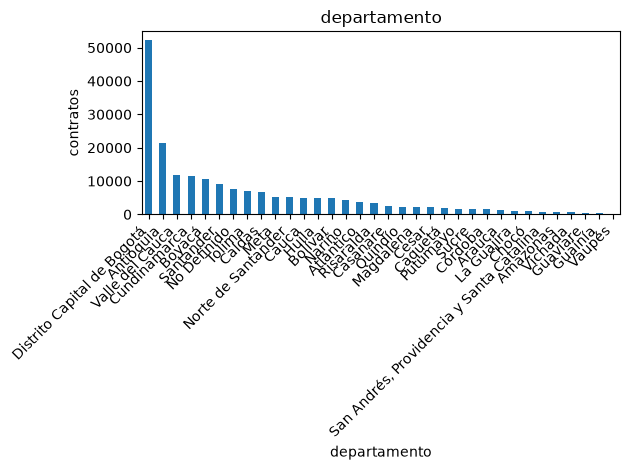

In [114]:
print(df['departamento'].value_counts(dropna=False))
print()
print(df['departamento'].value_counts(dropna=False, normalize=True))
print("Nulos:", df['departamento'].isna().sum())
print("Categorías:", df['departamento'].nunique())

df['departamento'].value_counts().plot(kind='bar')
plt.xlabel('departamento')
plt.ylabel('contratos')
plt.title('departamento')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


Conclusión: `departamento` es categórica, **34 etiquetas**, sin nulos y sin duplicados por mayúsculas.

- Concentración geográfica: **Bogotá 26.6%**, Antioquia 10.9%, Valle 6.0%, Cundinamarca 5.8%. El resto se reparte en los demás departamentos.
- Calidad: `No Definido` son **7,510 (3.8%)**. No se va a imputar; en análisis posteriores se puede dejar aparte o excluir de tasas por territorio.

## 1.2. Problemas de calidad y tratamiento

El dataset tiene **196,391 filas × 36 columnas**. Tipos: texto (entidad, sector, modalidad, estados), fechas de firma/inicio/fin, y numéricos (valores, días adicionados). No hay nulos explícitos en los 5 atributos prioritarios; la suciedad es de **valores imposibles, ceros sin sentido y etiquetas basura**.

| Problema | Atributo | Tratamiento |
|---|---|---|
| Máximo 14,276 días (~39 años) | `dias_adicionados` | Nulo en `dias_adicionados_v2`; se conserva la fila |
| Máximo 12.86e15 COP (3 bienes) | `valor_del_contrato` | Nulo en `valor_del_contrato_v2` |
| 188 contratos con valor 0 | `valor_del_contrato` | Nulo en `v2` (no es un contrato de bienes creíble) |
| 54.8% con pagado = 0 | `valor_pagado` | **No** se borra: es la señal de subejecución |
| ~48.5% aún abiertos | `estado_contrato` | Se filtran `En ejecución`, `Modificado`, `Aprobado`, `Suspendido` antes de outcomes |
| `No aplica/No pertenece` 12.5% | `sector` | Se reporta; no se usa como sector real en focalización |
| `No Definido` 3.8% | `departamento` | Se deja aparte |
| Familias partidas (directa / régimen especial) | `modalidad_de_contratacion` | Se agrupan si hace falta para tests |

Las columnas `*_v2` se van a usar de aquí en adelante para plazo y valor contratado. El recorte a contratos cerrados/terminados se aplica en el punto 2.


# 2. Estrategia de análisis

La oficina necesita **reglas de focalización al firmar** para hacer un seguimiento a aquellos contratos que estadísticamente tienen más riesgo de tener alguna desviación, siendo esta de tiempo, de recursos o de cierre.

## 2.1. Variables del análisis

Las tres desviaciones que menciona el enunciado se traducen en tres **variables de resultado binarias**, que solo se conocen cuando el contrato ya se ejecutó:

| Desviación | Variable de resultado | Definición |
|---|---|---|
| Plazo | `flag_plazo` | `dias_adicionados_v2 > 0` |
| Recursos | `flag_recursos` | `valor_pagado = 0`, o `valor_pagado / valor_del_contrato_v2 < 0.8` |
| Cierre | `flag_cierre` | `liquidaci_n = No` |

Las **variables explicativas** son solo las que la oficina conoce el día de la firma, porque la regla de focalización se tiene que poder aplicar en ese momento: `valor_del_contrato_v2` (y su tercil), `modalidad_de_contratacion`, `sector`, `destino_gasto`, `orden`, `tipo_de_contrato`, `departamento` y `es_pyme`. Se excluyen a propósito `valor_pagado`, `dias_adicionados` y `estado_contrato` como explicativas: son consecuencia de la ejecución, no información disponible en la firma.

## 2.2. Preguntas y pruebas

Cada pregunta se plantea con $H_0$ / $H_1$ explícitas y $\alpha = 0.05$, y se reportan tanto los resultados significativos como los que no lo son:

- **¿Hay sectores más propensos a desviarse?** Tabla de contingencia `sector` × cada flag y prueba **chi-cuadrado de independencia** (`chi2_contingency`), con revisión de frecuencias esperadas, **V de Cramér** como tamaño de efecto y **residuos estandarizados** `(observado - esperado) / sqrt(esperado)` para ver qué sector empuja el resultado. $H_0$: la tasa de desviación es igual en todos los sectores. (3.1)
- **¿La modalidad de contratación cambia el riesgo?** Mismo chi-cuadrado sobre `modalidad_de_contratacion` × cada flag. Si quedan celdas con esperados bajos se agrupan las familias partidas (contratación directa, régimen especial). Luego se comparan dos modalidades concretas (régimen especial vs mínima cuantía) con **t de Welch** sobre la tasa 0/1 y su **IC 95%** de la diferencia de proporciones. (3.2)
- **¿Los contratos grandes se desvían más?** Se parte `valor_del_contrato_v2` en terciles y se aplica el mismo chi-cuadrado de tercil × cada flag, con V de Cramér y residuos. El tercil es un corte que la oficina puede aplicar al firmar. (3.3)
- **¿El destino del gasto (funcionamiento vs inversión) importa?** Chi-cuadrado de `destino_gasto` × cada flag; con solo dos categorías se reporta también la diferencia de proporciones y su IC. (3.4)
- **¿Las tres desviaciones ocurren en los mismos contratos?** Chi-cuadrado entre pares de flags, para saber si la oficina necesita un criterio o tres. (3.5)
- **Visualización multivariada** para leer los cruces que las pruebas miran por separado: barras agrupadas de tasa por modalidad y destino, y **heatmap** `sector` × `modalidad` con el % de desviación. (3.6)


Antes de mirar cualquier p-valor se fija un **umbral práctico**: una diferencia de **10 puntos porcentuales** frente a la tasa global es lo mínimo que cambiaría a quién se supervisa. Con ~100 mil contratos casi cualquier diferencia sale significativa. Un sector entra a la focalización solo si se aleja 10 puntos o más de esa tasa y tiene n suficiente. El residuo estandarizado dice qué celda empuja el chi-cuadrado; no dice si ese salto le sirve a la oficina. No se usan modelos de machine learning: el entregable son criterios auditables.

Vamos a utilizar un nivel de sensibilidad del 5%, suponiendo que se validó con los expertos de negocio.

## 2.3. Universo y periodo de análisis

**Solo contratos ya terminados.** Las tres variables de resultado no son observables en un contrato vivo: un contrato `En ejecución` con `valor_pagado = 0` no está subejecutado, simplemente todavía no le han pagado. Por eso el universo se restringe a `estado_contrato` en `Cerrado`, `terminado`, `cedido` y `Modificado`, y además se exige que `fecha_de_fin_del_contrato` ya haya pasado. Se excluyen `En ejecución`, `Aprobado` (91% sin pago: son contratos que nunca arrancaron) y `Suspendido`.

**`Modificado` se conserva a propósito.** Es el estado donde queda registrada la adición de plazo: el 49.8% de los `Modificado` tiene `dias_adicionados > 0` y ahí está el **91.8% de todas las adiciones del dataset** (17,147 de 18,671). Si se excluyera, `flag_plazo` caería a 0.4% y la primera desviación del enunciado quedaría sin datos. La contrapartida es que `estado_contrato` no se puede usar como variable explicativa, porque es casi lo mismo que el outcome de plazo.

**Periodo 2020–2024.** El recorte se hace por comparabilidad entre cohortes, mirando la cobertura del universo y las tasas por año de firma:

| Año firma | % del año que entra al universo | % con adición | % sin pago | % sin liquidar |
|---|---|---|---|---|
| 2019 | 67.5% | 6.1% | 64.5% | 55.8% |
| 2020 | 72.4% | 10.7% | 56.9% | 64.5% |
| 2021 | 73.1% | 10.1% | 53.1% | 67.3% |
| 2022 | 72.8% | 9.0% | 45.9% | 63.6% |
| 2023 | 69.2% | 10.8% | 45.3% | 53.8% |
| 2024 | 69.4% | 12.5% | 39.6% | 50.1% |
| 2025 | 50.7% | 17.0% | 38.0% | 48.6% |

- **2019 se excluye** por un problema de registro, no por su tamaño: el 32.4% de sus contratos quedó en estado `Aprobado` (contra ~1% en los demás años) y no tiene ni un solo registro `En ejecución`, lo que indica que los estados de ese año se cargaron con otra lógica. Su tasa de adiciones (6.1%) es casi la mitad de la de los años siguientes, y esa diferencia es de registro, no de gestión contractual.
- **2025 se excluye** por censura a la derecha: solo la mitad del año entra al universo (50.7% vs ~70%) y los contratos que ya terminaron son los más cortos, así que la muestra no es representativa del año.
- Quedan **99,444 contratos** firmados entre 2020 y 2024, suficientes para cruces por modalidad y sector sin celdas vacías.

In [115]:
ALPHA = 0.05

# 3. Ejecución de la estrategia

In [116]:
analisis = df[
    df["estado_contrato"].isin(["Cerrado", "terminado", "cedido", "Modificado"])
    & (pd.to_datetime(df["fecha_de_fin_del_contrato"]) <= pd.Timestamp("2025-12-31"))
    & df["fecha_de_firma"].between("2020-01-01", "2024-12-31")
].copy()

analisis["flag_plazo"] = analisis["dias_adicionados_v2"] > 0
analisis["flag_recursos"] = (analisis["valor_pagado"] == 0) | (
    analisis["valor_pagado"] / analisis["valor_del_contrato_v2"] < 0.8
)
analisis["flag_cierre"] = analisis["liquidaci_n"].eq("No")
analisis.shape


(99444, 41)

## 3.1. ¿Hay sectores más propensos a desviarse?

In [117]:
# H0: la tasa de desviación es igual en todos los sectores.
# H1: la tasa de desviación es diferente en al menos un sector.

# Calcular la tasa de desviación para cada sector
tasas = analisis.groupby("sector").agg(
    n=("sector", "size"),
    plazo=("flag_plazo", "mean"),
    recursos=("flag_recursos", "mean"),
    cierre=("flag_cierre", "mean"),
).sort_values("n", ascending=False)
print(tasas)

                                                        n  plazo  recursos  \
sector                                                                       
defensa                                             20628   0.09      0.56   
Servicio Público                                    17297   0.12      0.46   
Salud y Protección Social                           11674   0.10      0.77   
No aplica/No pertenece                              11380   0.10      0.49   
Ley de Justicia                                      9013   0.07      0.49   
Trabajo                                              8924   0.17      0.23   
Educación Nacional                                   4784   0.12      0.42   
Ambiente y Desarrollo Sostenible                     3920   0.10      0.44   
Transporte                                           2141   0.10      0.66   
Cultura                                              1378   0.11      0.35   
deportes                                             1373   0.09

In [118]:
# H0: la tasa del flag es igual en todos los sectores.
# H1: al menos un sector tiene una tasa distinta.
# "No aplica/No pertenece" se excluye de la prueba porque no es un sector.
# El chi-cuadrado dice si hay asociación. Los residuos estandarizados dicen en qué sector.

UMBRAL = 0.10
sectores = analisis[analisis["sector"] != "No aplica/No pertenece"].copy()


def cramers_v(chi2, n, r, k):
    phi2 = chi2 / n
    phi2_corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    r_corr = r - ((r - 1) ** 2) / (n - 1)
    k_corr = k - ((k - 1) ** 2) / (n - 1)
    return (phi2_corr / max(1e-12, min(r_corr - 1, k_corr - 1))) ** 0.5


for flag, nombre in [("flag_plazo", "plazo"), ("flag_recursos", "recursos"), ("flag_cierre", "cierre")]:
    print(f"\n=== sector × {nombre} ===")
    print()
    tabla = pd.crosstab(sectores["sector"], sectores[flag])
    chi2, p_value, dof, expected = stats.chi2_contingency(tabla)
    n = int(tabla.values.sum())
    r, k = tabla.shape
    v = cramers_v(chi2, n, r, k)

    print(f"chi2 = {chi2:.1f}   gl = {dof}   p-valor = {p_value:.4g}   V de Cramér = {v:.3f}")
    print(f"Frecuencia esperada mínima = {expected.min():.2f}   celdas < 5: {(expected < 5).sum()} de {expected.size}")
    if p_value < ALPHA:
        print(f"Rechazamos H0: la tasa de {nombre} no es igual en todos los sectores.")
    else:
        print(f"No rechazamos H0: no hay evidencia de que la tasa de {nombre} difiera entre sectores.")

    tasa_global = sectores[flag].mean()
    resumen = sectores.groupby("sector")[flag].agg(n="size", tasa="mean")
    resumen["diferencia"] = resumen["tasa"] - tasa_global
    resumen = resumen.sort_values("diferencia", ascending=False)
    print(f"Tasa global de {nombre}: {tasa_global:.3f}")
    print(f"Sectores a {UMBRAL:.0%} o más de la tasa global:")
    print(resumen[resumen["diferencia"].abs() >= UMBRAL])
    print()

    esperados = pd.DataFrame(expected, index=tabla.index, columns=tabla.columns)
    residuos = (tabla - esperados) / (esperados ** 0.5)
    residuos = residuos.rename(columns={False: "sin_desviacion", True: "con_desviacion"})

    # Con este n casi todo |residuo| > 2. Se imprimen los sectores que superan
    # el umbral de 10 pp y, si no está ya, el de mayor |residuo|.
    importantes = resumen.index[resumen["diferencia"].abs() >= UMBRAL]
    extremo = residuos["con_desviacion"].abs().idxmax()
    a_notar = importantes.union([extremo])
    print("Residuos a notar (|valor| > 2 empuja el chi-cuadrado):")
    print(residuos.loc[a_notar].sort_values("con_desviacion", ascending=False))




=== sector × plazo ===

chi2 = 762.3   gl = 23   p-valor = 3.166e-146   V de Cramér = 0.092
Frecuencia esperada mínima = 3.68   celdas < 5: 1 de 48
Rechazamos H0: la tasa de plazo no es igual en todos los sectores.
Tasa global de plazo: 0.108
Sectores a 10% o más de la tasa global:
            n  tasa  diferencia
sector                         
interior  451  0.22        0.11

Residuos a notar (|valor| > 2 empuja el chi-cuadrado):
flag_plazo  sin_desviacion  con_desviacion
sector                                    
Trabajo              -5.98           17.17
interior             -2.45            7.03

=== sector × recursos ===

chi2 = 7782.8   gl = 23   p-valor = 0   V de Cramér = 0.297
Frecuencia esperada mínima = 16.60   celdas < 5: 0 de 48
Rechazamos H0: la tasa de recursos no es igual en todos los sectores.
Tasa global de recursos: 0.512
Sectores a 10% o más de la tasa global:
                                                        n  tasa  diferencia
sector                        

Conclusión: se rechaza $H_0$ en las tres pruebas. El sector se asocia con cade tipo de desviación de contrato, con una fuerza distinta en cada una. 

- **Plazo.** Tasa global **10.8%**, V de Cramér **0.09**: la asociación es detectable y pequeña. El único sector que supera el umbral es `interior` (**22%**, n = 451, +11 pp). `Trabajo` tiene el residuo más alto (+17) porque concentra muchos contratos por encima de lo esperado, pero su tasa es **17%**, a 6 puntos de la global, así que no cambia a quién se supervisa. Una celda esperada queda bajo 5 (Inteligencia Estratégica, n = 34); es 1 de 48 y no altera el resultado.
- **Recursos.** Tasa global **51%**, V de Cramér **0.30**, todas las celdas esperadas por encima de 5. Con n grande: `Salud y Protección Social` **77%** (n = 11,674, +26 pp) y `Trabajo` **23%** (n = 8,924, −28 pp). `Hacienda y Crédito Público` también queda abajo (**28%**, n = 1,199). Inteligencia Estratégica sale en **100%** con 34 contratos: se reporta y no se usa como criterio.
- **Cierre.** Tasa global **58%**, V de Cramér **0.30**. `defensa` está en **34%** (n = 20,628, −24 pp) y tiene el residuo más grande (−45): cierra con liquidación más seguido que el resto. Por encima del umbral, con n grande, quedan `Salud y Protección Social` y `Ley de Justicia` (**73%**, +15 pp).

Las tres desviaciones no caen en los mismos sectores. `interior` pesa en plazo, `Salud` en recursos y en cierre, `Trabajo` se desvía más en plazo y menos en recursos, y `defensa` se aparta sobre todo en el cierre. Para focalizar, el sector alcanza en recursos y en cierre. En plazo el único criterio que supera el umbral es `interior`.
